# MobileNetV3 Anti-Spoofing Pretrain - FINAL

Notebook này bám theo cấu trúc notebook MobileFaceNet + ArcFace của bạn, nhưng đổi sang bài toán anti-spoofing `live / spoof` có thể kiểm tra với camera thực tế.

Mục tiêu chính:

- MobileNetV3 pretrained ImageNet.
- 2-head: `binary live/spoof` là head deploy, `type print/replay` là head phụ.
- Batch cân bằng `50% live / 25% print / 25% replay`.
- Không tin mỗi accuracy. Chọn threshold trên validation bằng APCER/BPCER/ACER rồi khóa threshold để test.
- Export `.keras`, weights, TFLite và file threshold để dùng khi inference trước camera.

Runtime khuyến nghị: Colab GPU L4.


### 1. Khởi tạo & Tối ưu Hệ thống

In [ ]:
# 1. CÀI ĐẶT MÔI TRƯỜNG & THƯ VIỆN (SETUP)
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

from google.colab import drive
drive.mount("/content/drive")

!pip -q install -U pandas pillow scikit-learn matplotlib opencv-python-headless

import io
import json
import math
import random
import shutil
import subprocess
import tarfile
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

SEED = 20260608
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Dùng float32 để ổn định khi save/load/eval/export trên Colab.
mixed_precision.set_global_policy("float32")
AUTOTUNE = tf.data.AUTOTUNE

print(f"TensorFlow       : {tf.__version__}")
print(f"Precision policy : {mixed_precision.global_policy()}")
print(f"GPU list         : {tf.config.list_physical_devices('GPU')}")
!nvidia-smi


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 155.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 155.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 160.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 162.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pa

### 2. Hyperparameter Config

In [ ]:
# 2. HYPERPARAMETER CONFIG

RUN_DIR = "/content/drive/MyDrive/CelebA-Spoof/Data_Face-Anti-Spooring/runs/mobilenetv3_antispoof_realready_tf"

# Archive tạo từ prepare_celeba_spoof.ipynb. Nếu đường dẫn này không tồn tại,
# cell extract sẽ tự tìm file celeba_spoof_224.tar.gz trong MyDrive.
DATASET_ARCHIVE = "/content/drive/MyDrive/CelebA-Spoof/Data_Face-Anti-Spooring/archives/celeba_spoof_224.tar.gz"
DATASET_ROOT = "/content/celeba_spoof_224"

# Optional real-world holdout. Để None nếu chưa có.
# CSV tối thiểu: image_path,binary_id với live=0, spoof=1.
REAL_TEST_CSV = None
REAL_TEST_ROOT = None

# Model
IMAGE_SIZE = 224
BACKBONE_NAME = "MobileNetV3Large"
EMBEDDING_SIZE = 256
DROPOUT = 0.20
PRETRAINED = True

# Training
BATCH_SIZE = 128
EPOCHS = 30
FREEZE_EPOCHS = 3
SHUFFLE_BUFFER_SIZE = 50_000

# Optimizer
HEAD_LR = 1e-3
FINETUNE_LR = 1e-4
MIN_LR = 1e-6
WARMUP_EPOCHS = 2
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.03
TYPE_LOSS_WEIGHT = 0.40

# Practical threshold policy.
# APCER: spoof bị nhận nhầm là live. Khi deploy, chỉ số này cực kỳ quan trọng.
THRESHOLD_POLICY = "target_apcer"  # "target_apcer" hoặc "min_acer"
TARGET_APCER = 0.02

# Camera inference
CAMERA_CROP_SCALE = 1.45

RUN_DIR = Path(RUN_DIR)
DATASET_ARCHIVE = Path(DATASET_ARCHIVE)
DATASET_ROOT = Path(DATASET_ROOT)
MANIFEST_DIR = RUN_DIR / "manifests"
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
LOG_DIR = RUN_DIR / "logs"
EXPORT_DIR = RUN_DIR / "exports"
EVAL_RESULT_DIR = RUN_DIR / "eval_results"

for folder in [MANIFEST_DIR, CHECKPOINT_DIR, LOG_DIR, EXPORT_DIR, EVAL_RESULT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("--- CONFIG SUMMARY ---")
print(f"Output dir       : {RUN_DIR}")
print(f"Dataset archive  : {DATASET_ARCHIVE}")
print(f"Dataset root     : {DATASET_ROOT}")
print(f"Backbone         : {BACKBONE_NAME} | ImageNet pretrained={PRETRAINED}")
print(f"Image size       : {IMAGE_SIZE}")
print(f"Training         : epochs={EPOCHS}, freeze={FREEZE_EPOCHS}, batch={BATCH_SIZE}")
print(f"Loss             : CE(binary) + {TYPE_LOSS_WEIGHT} * CE(print/replay on spoof)")
print(f"Threshold policy : {THRESHOLD_POLICY}, target APCER={TARGET_APCER}")

--- CONFIG SUMMARY ---
Output dir       : /content/drive/MyDrive/CelebA-Spoof/Data_Face-Anti-Spooring/runs/mobilenetv3_antispoof_realready_tf
Dataset archive  : /content/drive/MyDrive/CelebA-Spoof/Data_Face-Anti-Spooring/archives/celeba_spoof_224.tar.gz
Dataset root     : /content/celeba_spoof_224
Backbone         : MobileNetV3Large | ImageNet pretrained=True
Image size       : 224
Training         : epochs=30, freeze=3, batch=128
Loss             : CE(binary) + 0.4 * CE(print/replay on spoof)
Threshold policy : target_apcer, target APCER=0.02


### 3. Quản lý Dữ liệu

In [ ]:
# 3. EXTRACT DATASET

def find_archive(default_path):
    default_path = Path(default_path)
    if default_path.exists():
        return default_path

    print("[INFO] Default archive not found. Searching MyDrive for celeba_spoof_224.tar.gz ...")
    matches = list(Path("/content/drive/MyDrive").rglob("celeba_spoof_224.tar.gz"))
    if matches:
        matches = sorted(matches, key=lambda p: len(str(p)))
        print("[INFO] Found archive:", matches[0])
        return matches[0]
    raise FileNotFoundError("Không tìm thấy celeba_spoof_224.tar.gz trong MyDrive.")


def safe_extract_tar_gz(archive_path, extract_to="/content"):
    archive_path = Path(archive_path)
    extract_to = Path(extract_to).resolve()
    with tarfile.open(archive_path, "r:gz") as tar:
        for member in tar.getmembers():
            target = (extract_to / member.name).resolve()
            if not str(target).startswith(str(extract_to)):
                raise RuntimeError(f"Unsafe path in tar: {member.name}")
        tar.extractall(extract_to)


def extract_dataset(archive_path, dataset_root):
    archive_path = find_archive(archive_path)
    dataset_root = Path(dataset_root)

    if (dataset_root / "metadata" / "train.csv").exists():
        print(f"[INFO] Dataset already exists: {dataset_root}")
        return archive_path

    if dataset_root.exists():
        shutil.rmtree(dataset_root)

    print(f"[INFO] Extracting {archive_path.name} to /content ...")
    safe_extract_tar_gz(archive_path, "/content")

    if not (dataset_root / "metadata" / "train.csv").exists():
        raise FileNotFoundError(f"Extracted archive, but metadata/train.csv was not found under {dataset_root}")
    print(f"[INFO] Dataset ready: {dataset_root}")
    return archive_path


DATASET_ARCHIVE = extract_dataset(DATASET_ARCHIVE, DATASET_ROOT)


[INFO] Extracting celeba_spoof_224.tar.gz to /content ...


/tmp/ipykernel_382/4045201488.py:25: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_to)


[INFO] Dataset ready: /content/celeba_spoof_224


In [ ]:
# 4. BUILD MANIFESTS

def normalize_metadata(df):
    df = df.copy()

    if "binary_id" not in df.columns:
        if "binary_label" in df.columns:
            df["binary_id"] = df["binary_label"].map({"live": 0, "spoof": 1}).astype(int)
        else:
            raise ValueError("CSV cần binary_id hoặc binary_label.")

    if "type_id" not in df.columns:
        if "type_label" in df.columns:
            df["type_id"] = df["type_label"].map({"none": -1, "live": -1, "print": 0, "replay": 1}).astype(int)
        elif "macro_type" in df.columns:
            df["type_id"] = df["macro_type"].map({"live": -1, "print": 0, "replay": 1}).astype(int)
        else:
            df["type_id"] = -1

    if "macro_type" not in df.columns:
        df["macro_type"] = df["type_id"].map({-1: "unknown_spoof", 0: "print", 1: "replay"})
        df.loc[df["binary_id"].eq(0), "macro_type"] = "live"

    required = {"image_path", "binary_id", "type_id", "macro_type"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"CSV thiếu cột: {sorted(missing)}")
    return df


def load_split(split):
    csv_path = DATASET_ROOT / "metadata" / f"{split}.csv"
    df = normalize_metadata(pd.read_csv(csv_path))
    df["abs_path"] = df["image_path"].apply(lambda p: str(p) if Path(str(p)).is_absolute() else str(DATASET_ROOT / str(p)))
    return df.reset_index(drop=True)


train_df = load_split("train")
val_df = load_split("val")
test_df = load_split("test")

for split, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    out_csv = MANIFEST_DIR / f"{split}_manifest.csv"
    df.to_csv(out_csv, index=False)
    print(f"\n=== {split.upper()} ===")
    print("images:", len(df))
    print(df["macro_type"].value_counts().to_string())
    print("binary:")
    print(df["binary_id"].value_counts().sort_index().to_string())
    if "subject_id" in df.columns:
        print("subjects:", df["subject_id"].astype(str).nunique())

if all("subject_id" in df.columns for df in [train_df, val_df, test_df]):
    subject_sets = {
        "train": set(train_df["subject_id"].astype(str)),
        "val": set(val_df["subject_id"].astype(str)),
        "test": set(test_df["subject_id"].astype(str)),
    }
    print("\nLeak train/val :", len(subject_sets["train"] & subject_sets["val"]))
    print("Leak train/test:", len(subject_sets["train"] & subject_sets["test"]))
    print("Leak val/test  :", len(subject_sets["val"] & subject_sets["test"]))
    assert not (subject_sets["train"] & subject_sets["val"])
    assert not (subject_sets["train"] & subject_sets["test"])
    assert not (subject_sets["val"] & subject_sets["test"])
    print("[INFO] OK: không có subject leakage.")

assert set(["live", "print", "replay"]).issubset(set(train_df["macro_type"].unique())), "Train thiếu live/print/replay."
print("[INFO] Manifests are ready:", MANIFEST_DIR)



=== TRAIN ===
images: 321031
macro_type
live      146449
print      89684
replay     84898
binary:
binary_id
0    146449
1    174582
subjects: 7370

=== VAL ===
images: 35593
macro_type
live      15984
replay    10749
print      8860
binary:
binary_id
0    15984
1    19609
subjects: 820

=== TEST ===
images: 49646
macro_type
live      19923
print     15104
replay    14619
binary:
binary_id
0    19923
1    29723
subjects: 1002

Leak train/val : 0
Leak train/test: 0
Leak val/test  : 0
[INFO] OK: không có subject leakage.
[INFO] Manifests are ready: /content/drive/MyDrive/CelebA-Spoof/Data_Face-Anti-Spooring/runs/mobilenetv3_antispoof_realready_tf/manifests


### 4. Data Augmentation

In [ ]:
# 5. DATA AUGMENTATION

def random_jpeg(image):
    image_u8 = tf.cast(tf.clip_by_value(image, 0.0, 255.0), tf.uint8)
    image_u8 = tf.image.random_jpeg_quality(image_u8, min_jpeg_quality=35, max_jpeg_quality=95)
    return tf.cast(image_u8, tf.float32)


def augment_image(image):
    # Giữ augmentation vừa phải để không phá texture spoof như moire, reflection, mép giấy/màn hình.
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=24.0)
    image = tf.image.random_contrast(image, lower=0.75, upper=1.25)
    image = tf.image.random_saturation(image, lower=0.80, upper=1.20)
    image = tf.clip_by_value(image, 0.0, 255.0)

    image = tf.cond(tf.random.uniform([]) < 0.35, lambda: random_jpeg(image), lambda: image)
    noise = tf.random.normal(tf.shape(image), stddev=tf.random.uniform([], 0.0, 5.0))
    image = tf.cond(tf.random.uniform([]) < 0.15, lambda: tf.clip_by_value(image + noise, 0.0, 255.0), lambda: image)
    return image


### 5. TF.DATA Pipeline

In [ ]:
# 6. TF.DATA PIPELINE

def parse_sample(path, binary_id, type_id, training=False):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    image = tf.cast(image, tf.float32)

    if training:
        image = augment_image(image)

    binary_id = tf.cast(binary_id, tf.int32)
    type_id_raw = tf.cast(type_id, tf.int32)

    # Live có type_id=-1. Đưa nhãn dummy về 0 và đặt sample weight type=0 để ignore loss.
    type_weight = tf.cast(type_id_raw >= 0, tf.float32)
    type_id_for_loss = tf.where(type_id_raw >= 0, type_id_raw, tf.zeros_like(type_id_raw))

    y = {"binary": binary_id, "type": type_id_for_loss}
    sw = {"binary": tf.ones_like(type_weight), "type": type_weight}
    return image, y, sw


def df_to_dataset(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df["abs_path"].astype(str).values,
        df["binary_id"].astype(np.int32).values,
        df["type_id"].astype(np.int32).values,
    ))
    if training:
        ds = ds.shuffle(min(len(df), SHUFFLE_BUFFER_SIZE), seed=SEED, reshuffle_each_iteration=True).repeat()
    ds = ds.map(lambda p, b, t: parse_sample(p, b, t, training), num_parallel_calls=AUTOTUNE)
    return ds


def make_balanced_train_dataset(df):
    live_n = BATCH_SIZE // 2
    print_n = (BATCH_SIZE - live_n) // 2
    replay_n = BATCH_SIZE - live_n - print_n

    live_df = df[df["macro_type"].eq("live")]
    print_df = df[df["macro_type"].eq("print")]
    replay_df = df[df["macro_type"].eq("replay")]
    if min(len(live_df), len(print_df), len(replay_df)) == 0:
        raise ValueError("Train cần đủ live/print/replay để dùng balanced sampler.")

    live_ds = df_to_dataset(live_df, training=True).batch(live_n)
    print_ds = df_to_dataset(print_df, training=True).batch(print_n)
    replay_ds = df_to_dataset(replay_df, training=True).batch(replay_n)

    def merge_batches(live, print_, replay):
        images = tf.concat([live[0], print_[0], replay[0]], axis=0)
        y = {
            "binary": tf.concat([live[1]["binary"], print_[1]["binary"], replay[1]["binary"]], axis=0),
            "type": tf.concat([live[1]["type"], print_[1]["type"], replay[1]["type"]], axis=0),
        }
        sw = {
            "binary": tf.concat([live[2]["binary"], print_[2]["binary"], replay[2]["binary"]], axis=0),
            "type": tf.concat([live[2]["type"], print_[2]["type"], replay[2]["type"]], axis=0),
        }
        order = tf.random.shuffle(tf.range(tf.shape(images)[0]))
        images = tf.gather(images, order)
        y = {k: tf.gather(v, order) for k, v in y.items()}
        sw = {k: tf.gather(v, order) for k, v in sw.items()}
        return images, y, sw

    return tf.data.Dataset.zip((live_ds, print_ds, replay_ds)).map(merge_batches, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


def make_eval_dataset(df):
    return df_to_dataset(df, training=False).batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_balanced_train_dataset(train_df)
val_ds = make_eval_dataset(val_df)
test_ds = make_eval_dataset(test_df)
steps_per_epoch = math.ceil(len(train_df) / BATCH_SIZE)

real_test_ds = None
real_test_df = None
if REAL_TEST_CSV is not None:
    real_test_df = normalize_metadata(pd.read_csv(REAL_TEST_CSV))
    root = Path(REAL_TEST_ROOT) if REAL_TEST_ROOT is not None else Path(REAL_TEST_CSV).parent
    real_test_df["abs_path"] = real_test_df["image_path"].apply(lambda p: str(p) if Path(str(p)).is_absolute() else str(root / str(p)))
    real_test_ds = make_eval_dataset(real_test_df)

print("steps_per_epoch:", steps_per_epoch)
print("Batch mix        :", BATCH_SIZE // 2, "live |", (BATCH_SIZE - BATCH_SIZE // 2) // 2, "print |", BATCH_SIZE - BATCH_SIZE // 2 - (BATCH_SIZE - BATCH_SIZE // 2) // 2, "replay")


steps_per_epoch: 2509
Batch mix        : 64 live | 32 print | 32 replay


### 6. Backbone And Anti-Spoof Model

In [ ]:
# 7. BACKBONE: MOBILENETV3

def build_mobilenetv3_backbone():
    # Input là RGB float32 [0,255]. MobileNetV3 include_preprocessing=True sẽ tự preprocess.
    return tf.keras.applications.MobileNetV3Large(
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
        include_top=False,
        weights="imagenet" if PRETRAINED else None,
        include_preprocessing=True,
        pooling=None,
    )


def build_antispoof_model():
    image = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="image")
    backbone = build_mobilenetv3_backbone()
    x = backbone(image, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(EMBEDDING_SIZE, use_bias=False, name="embedding_dense")(x)
    x = layers.BatchNormalization(name="embedding_bn")(x)
    x = layers.Activation("hard_swish", name="embedding_hswish")(x)
    x = layers.Dropout(DROPOUT, name="embedding_dropout")(x)

    binary_logits = layers.Dense(2, name="binary")(x)
    type_logits = layers.Dense(2, name="type")(x)
    model = tf.keras.Model(image, {"binary": binary_logits, "type": type_logits}, name="MobileNetV3_AntiSpoof_2Head")
    return model, backbone


model, backbone = build_antispoof_model()
model.summary()
print("Model params:", model.count_params())


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV3_AntiSpoof_2Head"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 7, 7, 960) │  2,996,352 │ image[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 960)       │          0 │ MobileNetV3Large… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dense     │ (None, 256)       │    245,760 │ gap[0][0]         │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_bn        │ (None, 256)       │      1,024 │ embedding_dense[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_hswish    │ (None, 256)       │          0 │ embedding_bn[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dropout   │ (None, 256)       │          0 │ embedding_hswish… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ binary (Dense)      │ (None, 2)         │        514 │ embedding_dropou… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type (Dense)        │ (None, 2)         │        514 │ embedding_dropou… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,244,164 (12.38 MB)

 Trainable params: 3,219,252 (12.28 MB)

 Non-trainable params: 24,912 (97.31 KB)

Model params: 3244164


In [ ]:
# 8. LOSS + MODEL HELPERS

def sparse_ce_with_smoothing(num_classes, name):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true = tf.one_hot(y_true, depth=num_classes, dtype=tf.float32)
        if LABEL_SMOOTHING > 0:
            y_true = y_true * (1.0 - LABEL_SMOOTHING) + LABEL_SMOOTHING / float(num_classes)
        return tf.keras.losses.categorical_crossentropy(y_true, y_pred, from_logits=True)

    loss_fn.__name__ = name
    return loss_fn


losses = {
    "binary": sparse_ce_with_smoothing(2, "binary_sparse_ce_smooth"),
    "type": sparse_ce_with_smoothing(2, "type_sparse_ce_smooth"),
}
loss_weights = {"binary": 1.0, "type": TYPE_LOSS_WEIGHT}
metrics = {"binary": [tf.keras.metrics.SparseCategoricalAccuracy(name="acc")]}


def compile_model(lr):
    optimizer = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=WEIGHT_DECAY)
    model.compile(
        optimizer=optimizer,
        loss=losses,
        loss_weights=loss_weights,
        metrics=metrics,
        steps_per_execution=50,
    )


def set_backbone_trainable(trainable):
    backbone.trainable = bool(trainable)
    print("[INFO] Backbone trainable:", backbone.trainable)


### 7. Training Strategy

In [ ]:
# 9. PRACTICAL EVALUATION HELPERS

def threshold_metrics(y_true, prob_spoof, threshold):
    y_true = np.asarray(y_true).astype(np.int32)
    prob_spoof = np.asarray(prob_spoof).astype(np.float32)
    pred_spoof = prob_spoof >= threshold
    spoof = y_true == 1
    live = y_true == 0
    apcer = float(np.sum(spoof & (~pred_spoof)) / max(1, np.sum(spoof)))
    bpcer = float(np.sum(live & pred_spoof) / max(1, np.sum(live)))
    acer = 0.5 * (apcer + bpcer)
    acc = float(accuracy_score(y_true, pred_spoof.astype(np.int32)))
    return {"threshold": float(threshold), "apcer": apcer, "bpcer": bpcer, "acer": acer, "accuracy": acc}


def choose_threshold(y_true, prob_spoof):
    thresholds = np.linspace(0.001, 0.999, 999)
    scored = [threshold_metrics(y_true, prob_spoof, t) for t in thresholds]
    if THRESHOLD_POLICY == "target_apcer":
        feasible = [m for m in scored if m["apcer"] <= TARGET_APCER]
        if feasible:
            return min(feasible, key=lambda m: (m["bpcer"], m["acer"], -m["threshold"]))
    return min(scored, key=lambda m: (m["acer"], m["apcer"], m["bpcer"]))


def eer_score(y_true, prob_spoof):
    fpr, tpr, _ = roc_curve(y_true, prob_spoof)
    fnr = 1.0 - tpr
    idx = int(np.nanargmin(np.abs(fnr - fpr)))
    return float((fpr[idx] + fnr[idx]) / 2.0)


def evaluate_dataset(ds, binary_threshold=None):
    all_binary = []
    all_prob_spoof = []
    all_type_true = []
    all_type_pred = []

    for images, y, sw in ds:
        outputs = model(images, training=False)
        prob_spoof = tf.nn.softmax(outputs["binary"], axis=-1)[:, 1].numpy()
        all_binary.append(y["binary"].numpy())
        all_prob_spoof.append(prob_spoof)

        type_weight = sw["type"].numpy()
        mask = type_weight > 0
        if np.any(mask):
            type_pred = tf.argmax(outputs["type"], axis=-1).numpy()
            all_type_true.append(y["type"].numpy()[mask])
            all_type_pred.append(type_pred[mask])

    y_true = np.concatenate(all_binary)
    prob_spoof = np.concatenate(all_prob_spoof)

    try:
        auc = float(roc_auc_score(y_true, prob_spoof))
        eer = eer_score(y_true, prob_spoof)
    except ValueError:
        auc = float("nan")
        eer = float("nan")

    if binary_threshold is None:
        tm = choose_threshold(y_true, prob_spoof)
    else:
        tm = threshold_metrics(y_true, prob_spoof, binary_threshold)

    if all_type_true:
        type_acc = float(accuracy_score(np.concatenate(all_type_true), np.concatenate(all_type_pred)))
    else:
        type_acc = float("nan")

    return {"auc": auc, "eer": eer, "type_acc": type_acc, **tm}


In [ ]:
# 10. COMPILE MODEL + CALLBACKS

BEST_WEIGHTS = CHECKPOINT_DIR / "best_val_acer.weights.h5"
LAST_WEIGHTS = CHECKPOINT_DIR / "last.weights.h5"
LOG_CSV = LOG_DIR / "training_log.csv"
VAL_HISTORY_JSONL = EVAL_RESULT_DIR / "val_history.jsonl"
THRESHOLD_JSON = EXPORT_DIR / "threshold_config.json"

if VAL_HISTORY_JSONL.exists():
    VAL_HISTORY_JSONL.unlink()


def lr_schedule(epoch, current_lr):
    # Epoch truyền vào tính từ mỗi phase fit. Dùng schedule mềm, còn phase 2 sẽ compile LR thấp hơn.
    epoch_num = epoch + 1
    if epoch_num <= WARMUP_EPOCHS:
        p = (epoch_num - 1) / max(1, WARMUP_EPOCHS - 1)
        return current_lr + p * (current_lr - current_lr)
    p = epoch_num / max(1, EPOCHS)
    return max(MIN_LR, float(current_lr) * (0.5 * (1.0 + math.cos(math.pi * min(1.0, p)))))


class AntiSpoofEvalCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.best_acer = float("inf")
        self.best_threshold = 0.5
        self.best_epoch = -1

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_metrics = evaluate_dataset(val_ds, binary_threshold=None)
        for key, value in val_metrics.items():
            logs[f"val_{key}"] = value

        row = {"epoch": int(epoch + 1), "val": val_metrics}
        with open(VAL_HISTORY_JSONL, "a", encoding="utf-8") as f:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

        print(
            "\n[VAL] "
            f"auc={val_metrics['auc']:.4f} "
            f"eer={val_metrics['eer']:.4f} "
            f"apcer={val_metrics['apcer']:.4f} "
            f"bpcer={val_metrics['bpcer']:.4f} "
            f"acer={val_metrics['acer']:.4f} "
            f"thr={val_metrics['threshold']:.3f}"
        )

        if val_metrics["acer"] < self.best_acer:
            self.best_acer = val_metrics["acer"]
            self.best_threshold = val_metrics["threshold"]
            self.best_epoch = epoch + 1
            self.model.save_weights(BEST_WEIGHTS)
            print(f"[INFO] Saved best weights: {BEST_WEIGHTS}")


eval_callback = AntiSpoofEvalCallback()

callbacks = [
    eval_callback,
    tf.keras.callbacks.CSVLogger(str(LOG_CSV), append=False),
    tf.keras.callbacks.TerminateOnNaN(),
]

print("[INFO] Best checkpoint monitor: minimum val ACER with threshold selected on val.")


[INFO] Best checkpoint monitor: minimum val ACER with threshold selected on val.


In [ ]:
# 11. TRAINING

print("Starting training...")
start_time = time.time()

# Stage 1: train heads only.
if FREEZE_EPOCHS > 0:
    set_backbone_trainable(False)
    compile_model(HEAD_LR)
    history_stage1 = model.fit(
        train_ds,
        epochs=FREEZE_EPOCHS,
        steps_per_epoch=steps_per_epoch,
        callbacks=callbacks,
        verbose=1,
    )
else:
    history_stage1 = None

# Stage 2: fine-tune all layers with lower LR.
remaining_epochs = max(0, EPOCHS - FREEZE_EPOCHS)
if remaining_epochs > 0:
    set_backbone_trainable(True)
    compile_model(FINETUNE_LR)
    history_stage2 = model.fit(
        train_ds,
        initial_epoch=FREEZE_EPOCHS,
        epochs=EPOCHS,
        steps_per_epoch=steps_per_epoch,
        callbacks=callbacks,
        verbose=1,
    )
else:
    history_stage2 = None

model.save_weights(LAST_WEIGHTS)
elapsed = (time.time() - start_time) / 60
print(f"Training finished in {elapsed:.2f} minutes.")
print("Best epoch:", eval_callback.best_epoch)
print("Best val ACER:", eval_callback.best_acer)
print("Best threshold:", eval_callback.best_threshold)


Starting training...
[INFO] Backbone trainable: False
Epoch 1/3
2550/2509 ━━━━━━━━━━━━━━━━━━━━ -3s 93ms/step - binary_acc: 0.9315 - binary_loss: 0.2286 - loss: 0.2990 - type_loss: 0.1760
[VAL] auc=0.9924 eer=0.0417 apcer=0.0199 bpcer=0.0865 acer=0.0532 thr=0.215
[INFO] Saved best weights: /content/drive/MyDrive/CelebA-Spoof/Data_Face-Anti-Spooring/runs/mobilenetv3_antispoof_realready_tf/checkpoints/best_val_acer.weights.h5
2509/2509 ━━━━━━━━━━━━━━━━━━━━ 294s 117ms/step - binary_acc: 0.9430 - binary_loss: 0.2064 - loss: 0.2689 - type_loss: 0.1563 - val_auc: 0.9924 - val_eer: 0.0417 - val_type_acc: 0.8880 - val_threshold: 0.2150 - val_apcer: 0.0199 - val_bpcer: 0.0865 - val_acer: 0.0532 - val_accuracy: 0.9502
Epoch 2/3
2550/2509 ━━━━━━━━━━━━━━━━━━━━ -3s 79ms/step - binary_acc: 0.9564 - binary_loss: 0.1811 - loss: 0.2344 - type_loss: 0.1331
[VAL] auc=0.9932 eer=0.0373 apcer=0.0200 bpcer=0.0734 acer=0.0467 thr=0.292
[INFO] Saved best weights: /content/drive/MyDrive/CelebA-Spoof/Data_Face-A

### 8. Save And Export

In [ ]:
# 12. SAVE AND EXPORT MODEL

FINAL_WEIGHTS = EXPORT_DIR / "mobilenetv3_antispoof_final.weights.h5"
BEST_MODEL = EXPORT_DIR / "mobilenetv3_antispoof_best.keras"
TFLITE_MODEL = EXPORT_DIR / "mobilenetv3_antispoof_best_float32.tflite"

if BEST_WEIGHTS.exists():
    print(f"Loading best weights from {BEST_WEIGHTS} before export...")
    model.load_weights(BEST_WEIGHTS)
else:
    print("Best weights not found, exporting last epoch weights.")

model.save_weights(FINAL_WEIGHTS)
model.save(BEST_MODEL)

threshold_config = {
    "threshold_from_val": float(eval_callback.best_threshold),
    "threshold_policy": THRESHOLD_POLICY,
    "target_apcer": TARGET_APCER,
    "input": {
        "image_size": IMAGE_SIZE,
        "color": "RGB",
        "range": "[0,255]",
        "face_crop_scale": CAMERA_CROP_SCALE,
        "note": "Model includes MobileNetV3 preprocessing. Feed RGB float/image resized to 224x224.",
    },
    "class_map": {
        "binary": {"live": 0, "spoof": 1},
        "type": {"print": 0, "replay": 1, "live_ignore": -1},
    },
}
THRESHOLD_JSON.write_text(json.dumps(threshold_config, indent=2, ensure_ascii=False), encoding="utf-8")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_bytes = converter.convert()
TFLITE_MODEL.write_bytes(tflite_bytes)

print("Saved weights :", FINAL_WEIGHTS)
print("Saved model   :", BEST_MODEL)
print("Saved TFLite  :", TFLITE_MODEL)
print("Saved config  :", THRESHOLD_JSON)


Loading best weights from /content/drive/MyDrive/CelebA-Spoof/Data_Face-Anti-Spooring/runs/mobilenetv3_antispoof_realready_tf/checkpoints/best_val_acer.weights.h5 before export...
Saved artifact at '/tmp/tmphhq47ygx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  Dict[['binary', TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)], ['type', TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)]]
Captures:
  134076243310928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134075902592400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134075902591056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134076243311696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134076243312464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134076243310352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134075902592208: TensorSpec(shape=(

### 9. Final Evaluation

In [ ]:
# 13. FINAL EVALUATION ON TEST / REAL HOLDOUT

if BEST_WEIGHTS.exists():
    model.load_weights(BEST_WEIGHTS)

threshold = float(eval_callback.best_threshold)
val_metrics = evaluate_dataset(val_ds, binary_threshold=threshold)
test_metrics = evaluate_dataset(test_ds, binary_threshold=threshold)

summary = {
    "best_epoch": int(eval_callback.best_epoch),
    "threshold_from_val": threshold,
    "val_locked_threshold": val_metrics,
    "test_locked_threshold": test_metrics,
}

if real_test_ds is not None:
    summary["real_test_locked_threshold"] = evaluate_dataset(real_test_ds, binary_threshold=threshold)

if test_metrics["acer"] - val_metrics["acer"] > 0.10:
    summary["warning"] = "Val-test ACER gap lớn. Có dấu hiệu overfit/domain shortcut, chưa nên deploy."
if "real_test_locked_threshold" in summary and summary["real_test_locked_threshold"]["acer"] - val_metrics["acer"] > 0.10:
    summary["real_warning"] = "Val-real ACER gap lớn. Cần fine-tune/evaluate trên target-domain data trước khi deploy."

FINAL_EVAL_JSON = EVAL_RESULT_DIR / "final_test_report.json"
FINAL_EVAL_JSON.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

print("\nFINAL REPORT")
print("-" * 88)
for name, metrics_ in summary.items():
    if isinstance(metrics_, dict) and "acer" in metrics_:
        print(
            f"{name:<30} "
            f"AUC={metrics_['auc']:.4f} "
            f"EER={metrics_['eer']:.4f} "
            f"APCER={metrics_['apcer']:.4f} "
            f"BPCER={metrics_['bpcer']:.4f} "
            f"ACER={metrics_['acer']:.4f} "
            f"ACC={metrics_['accuracy']:.4f}"
        )

print("\nSaved final eval:", FINAL_EVAL_JSON)
print(json.dumps(summary, indent=2, ensure_ascii=False))



FINAL REPORT
----------------------------------------------------------------------------------------
val_locked_threshold           AUC=0.9993 EER=0.0040 APCER=0.0162 BPCER=0.0008 ACER=0.0085 ACC=0.9908
test_locked_threshold          AUC=0.9645 EER=0.0662 APCER=0.2574 BPCER=0.0013 ACER=0.1293 ACC=0.8454

Saved final eval: /content/drive/MyDrive/CelebA-Spoof/Data_Face-Anti-Spooring/runs/mobilenetv3_antispoof_realready_tf/eval_results/final_test_report.json
{
  "best_epoch": 20,
  "threshold_from_val": 0.875,
  "val_locked_threshold": {
    "auc": 0.9993025210686742,
    "eer": 0.003959603376644006,
    "type_acc": 0.9770003569789383,
    "threshold": 0.875,
    "apcer": 0.016166046203274005,
    "bpcer": 0.0007507507507507507,
    "acer": 0.008458398477012378,
    "accuracy": 0.9907566094456776
  },
  "test_locked_threshold": {
    "auc": 0.9644787851591512,
    "eer": 0.0662332167723034,
    "type_acc": 0.9130976011842681,
    "threshold": 0.875,
    "apcer": 0.2574100864650271,
    

    epoch  binary_acc  binary_loss      loss  type_loss  val_accuracy  \
22     25    0.999623     0.078954  0.095296   0.040856      0.989324   
23     26    0.999605     0.079094  0.095376   0.040707      0.990532   
24     27    0.999580     0.079088  0.095324   0.040589      0.989239   
25     28    0.999599     0.079083  0.095251   0.040420      0.988874   
26     29    0.999678     0.078900  0.095147   0.040616      0.988649   

    val_acer  val_apcer   val_auc  val_bpcer   val_eer  val_threshold  \
22  0.009741   0.018920  0.998148   0.000563  0.004016          0.947   
23  0.008709   0.016166  0.999466   0.001251  0.004383          0.937   
24  0.009841   0.018869  0.997210   0.000813  0.005084          0.881   
25  0.010173   0.019532  0.999343   0.000813  0.003991          0.961   
26  0.010371   0.019991  0.998391   0.000751  0.004522          0.932   

    val_type_acc  
22      0.976184  
23      0.968943  
24      0.972870  
25      0.980978  
26      0.979499  


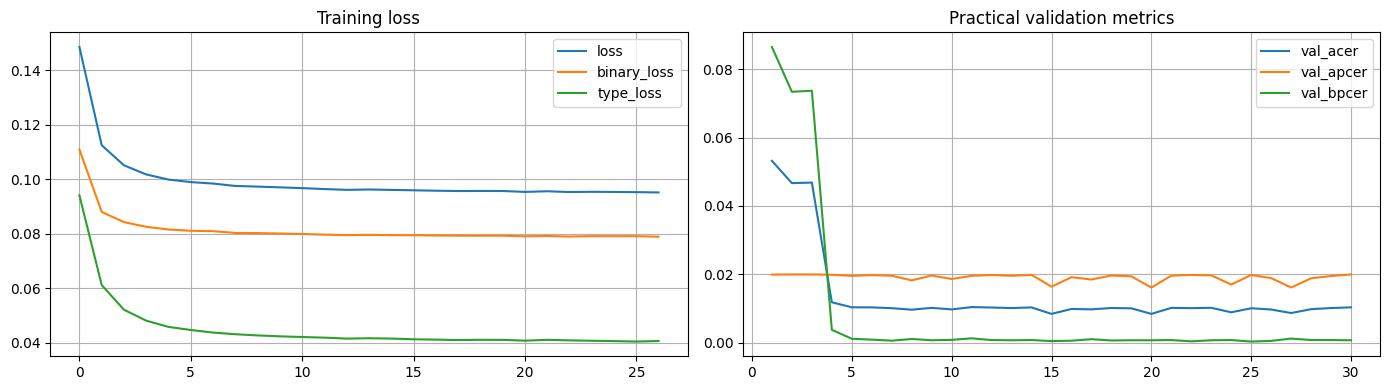

In [ ]:
# 14. TRAINING CURVES

log_path = Path(LOG_CSV)
if log_path.exists():
    log_df = pd.read_csv(log_path)
    print(log_df.tail())

    plt.figure(figsize=(14, 4))
    plt.subplot(1, 2, 1)
    for col in ["loss", "binary_loss", "type_loss"]:
        if col in log_df.columns:
            plt.plot(log_df[col], label=col)
    plt.title("Training loss")
    plt.legend()
    plt.grid(True)

    val_rows = []
    if VAL_HISTORY_JSONL.exists():
        for line in VAL_HISTORY_JSONL.read_text(encoding="utf-8").splitlines():
            if line.strip():
                row = json.loads(line)
                val_rows.append({"epoch": row["epoch"], **row["val"]})
    if val_rows:
        val_log = pd.DataFrame(val_rows)
        plt.subplot(1, 2, 2)
        plt.plot(val_log["epoch"], val_log["acer"], label="val_acer")
        plt.plot(val_log["epoch"], val_log["apcer"], label="val_apcer")
        plt.plot(val_log["epoch"], val_log["bpcer"], label="val_bpcer")
        plt.title("Practical validation metrics")
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("No training log found.")


### 10. Camera Smoke Test

In [ ]:
# 15. OPTIONAL: TEST NHANH BẰNG WEBCAM COLAB
# Cell này dùng để kiểm tra nhanh sau train. Kết quả thực tế vẫn phải dựa vào real holdout có split rõ ràng.

from base64 import b64decode
from IPython.display import Javascript, display
from google.colab.output import eval_js


def take_photo(filename="/content/camera.jpg", quality=0.90):
    js = Javascript(
        '''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const video = document.createElement('video');
          const button = document.createElement('button');
          button.textContent = 'Capture';
          div.appendChild(video);
          div.appendChild(button);
          document.body.appendChild(div);
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          video.srcObject = stream;
          await video.play();
          google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
          await new Promise((resolve) => button.onclick = resolve);
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getVideoTracks()[0].stop();
          div.remove();
          return canvas.toDataURL('image/jpeg', quality);
        }
        '''
    )
    display(js)
    data = eval_js(f"takePhoto({quality})")
    binary = b64decode(data.split(",")[1])
    Path(filename).write_bytes(binary)
    return filename


def crop_face_bgr(image_bgr, scale=1.45):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    detector = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(80, 80))
    if len(faces) == 0:
        return image_bgr, None
    x, y, w, h = max(faces, key=lambda r: r[2] * r[3])
    cx, cy = x + w / 2, y + h / 2
    side = max(w, h) * scale
    x1, y1 = int(cx - side / 2), int(cy - side / 2)
    x2, y2 = int(cx + side / 2), int(cy + side / 2)
    H, W = image_bgr.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(W, x2), min(H, y2)
    return image_bgr[y1:y2, x1:x2], (x1, y1, x2, y2)


def predict_image_file(path):
    image_bgr = cv2.imread(str(path))
    if image_bgr is None:
        raise ValueError(f"Cannot read image: {path}")
    crop_bgr, box = crop_face_bgr(image_bgr, CAMERA_CROP_SCALE)
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(crop_rgb, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA).astype(np.float32)
    pred = model(np.expand_dims(resized, 0), training=False)
    prob_spoof = float(tf.nn.softmax(pred["binary"], axis=-1)[0, 1].numpy())
    type_prob = tf.nn.softmax(pred["type"], axis=-1)[0].numpy()
    threshold = float(json.loads(THRESHOLD_JSON.read_text(encoding="utf-8"))["threshold_from_val"])
    label = "SPOOF" if prob_spoof >= threshold else "LIVE"
    attack_type = "print" if type_prob[0] >= type_prob[1] else "replay"
    return label, prob_spoof, threshold, attack_type, crop_rgb, box



photo_path = take_photo()
label, prob, thr, attack_type, crop_rgb, box = predict_image_file(photo_path)
print(f"Result: {label} | spoof_prob={prob:.4f} | threshold={thr:.4f} | type={attack_type} | face_box={box}")


<IPython.core.display.Javascript object>

Result: LIVE | spoof_prob=0.0590 | threshold=0.8750 | type=print | face_box=(164, 153, 503, 480)


### 11. Standalone Camera Smoke Test
Cell này dùng để load mô hình đã train từ Drive để kiểm tra với camera mà không cần chạy lại các bước training.

In [24]:
import cv2
import json
import numpy as np
import tensorflow as tf
from pathlib import Path
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

# --- CONFIG ---
# Cập nhật đường dẫn cho phù hợp nếu cần
RUN_DIR = Path("/content/drive/MyDrive/CelebA-Spoof/Data_Face-Anti-Spooring/runs/mobilenetv3_antispoof_realready_tf")
MODEL_PATH = RUN_DIR / "exports/mobilenetv3_antispoof_best.keras"
CONFIG_PATH = RUN_DIR / "exports/threshold_config.json"

# --- LOAD MODEL & CONFIG ---
print(f"[INFO] Loading model from: {MODEL_PATH}")
# Load with compile=False to bypass custom loss functions missing error during inference
loaded_model = tf.keras.models.load_model(MODEL_PATH, compile=False)

print(f"[INFO] Loading config from: {CONFIG_PATH}")
loaded_config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
loaded_threshold = float(loaded_config["threshold_from_val"])
IMAGE_SIZE = loaded_config["input"]["image_size"]
CAMERA_CROP_SCALE = loaded_config["input"]["face_crop_scale"]
print(f"[INFO] Configuration loaded. Threshold: {loaded_threshold}, Image size: {IMAGE_SIZE}, Crop scale: {CAMERA_CROP_SCALE}")

# --- CAMERA UTILS ---
def standalone_take_photo(filename="/content/camera_standalone.jpg", quality=0.90):
    js = Javascript(
        '''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const video = document.createElement('video');
          const button = document.createElement('button');
          button.textContent = 'Capture';
          div.appendChild(video);
          div.appendChild(button);
          document.body.appendChild(div);
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          video.srcObject = stream;
          await video.play();
          google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
          await new Promise((resolve) => button.onclick = resolve);
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getVideoTracks()[0].stop();
          div.remove();
          return canvas.toDataURL('image/jpeg', quality);
        }
        '''
    )
    display(js)
    data = eval_js(f"takePhoto({quality})")
    binary = b64decode(data.split(",")[1])
    Path(filename).write_bytes(binary)
    return filename

def standalone_crop_face_bgr(image_bgr, scale):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    detector = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(80, 80))
    if len(faces) == 0:
        return image_bgr, None
    x, y, w, h = max(faces, key=lambda r: r[2] * r[3])
    cx, cy = x + w / 2, y + h / 2
    side = max(w, h) * scale
    x1, y1 = int(cx - side / 2), int(cy - side / 2)
    x2, y2 = int(cx + side / 2), int(cy + side / 2)
    H, W = image_bgr.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(W, x2), min(H, y2)
    return image_bgr[y1:y2, x1:x2], (x1, y1, x2, y2)

def standalone_predict_image(path, model, threshold, image_size, crop_scale):
    image_bgr = cv2.imread(str(path))
    if image_bgr is None:
        raise ValueError(f"Cannot read image: {path}")
    crop_bgr, box = standalone_crop_face_bgr(image_bgr, crop_scale)
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(crop_rgb, (image_size, image_size), interpolation=cv2.INTER_AREA).astype(np.float32)

    pred = model(np.expand_dims(resized, 0), training=False)
    prob_spoof = float(tf.nn.softmax(pred["binary"], axis=-1)[0, 1].numpy())
    type_prob = tf.nn.softmax(pred["type"], axis=-1)[0].numpy()

    label = "SPOOF" if prob_spoof >= threshold else "LIVE"
    attack_type = "print" if type_prob[0] >= type_prob[1] else "replay"
    return label, prob_spoof, attack_type, crop_rgb, box

# --- RUN TEST ---
try:
    print("\n=> Please capture a photo for testing...")
    test_photo_path = standalone_take_photo()
    res_label, res_prob, res_attack_type, res_crop, res_box = standalone_predict_image(
        test_photo_path, loaded_model, loaded_threshold, IMAGE_SIZE, CAMERA_CROP_SCALE
    )
    print(f"\n=== PREDICTION RESULT ===")
    print(f"Label       : {res_label}")
    print(f"Spoof Prob  : {res_prob:.4f}")
    print(f"Threshold   : {loaded_threshold:.4f}")
    print(f"Attack Type : {res_attack_type}")
    print(f"Face Box    : {res_box}")
    print("=========================")
except Exception as e:
    print(f"Error during inference: {e}")

[INFO] Loading model from: /content/drive/MyDrive/CelebA-Spoof/Data_Face-Anti-Spooring/runs/mobilenetv3_antispoof_realready_tf/exports/mobilenetv3_antispoof_best.keras
[INFO] Loading config from: /content/drive/MyDrive/CelebA-Spoof/Data_Face-Anti-Spooring/runs/mobilenetv3_antispoof_realready_tf/exports/threshold_config.json
[INFO] Configuration loaded. Threshold: 0.875, Image size: 224, Crop scale: 1.45

=> Please capture a photo for testing...


<IPython.core.display.Javascript object>


=== PREDICTION RESULT ===
Label       : SPOOF
Spoof Prob  : 0.9595
Threshold   : 0.8750
Attack Type : print
Face Box    : (197, 145, 472, 420)


In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
